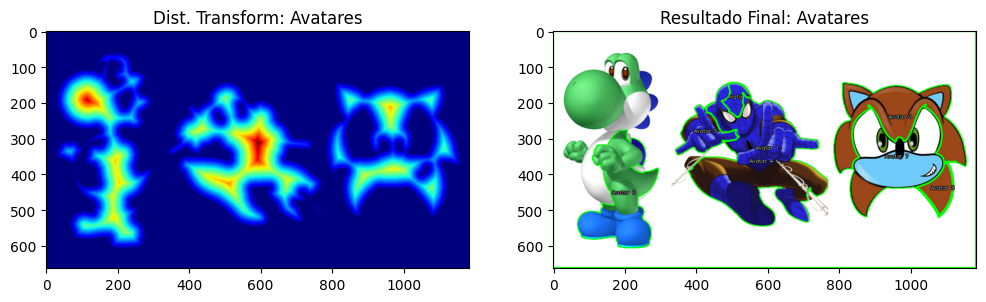

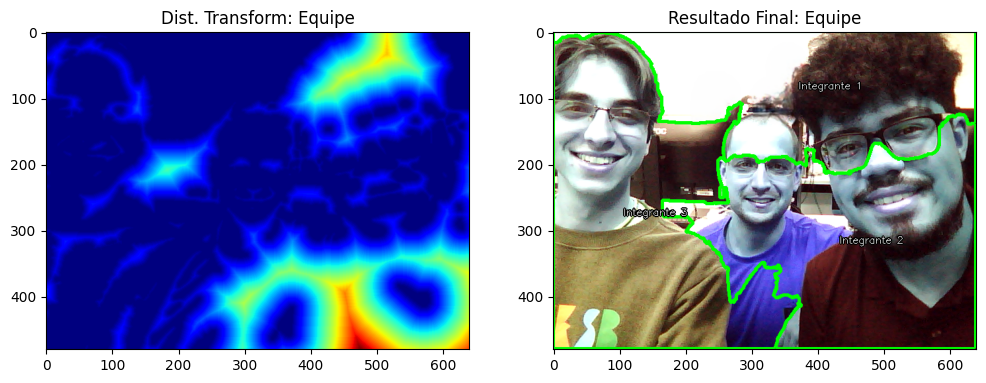

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from morph import *

# Inicialização da biblioteca
mm.install()

def pipeline_watershed(path_imagem, titulo, prefixo="Objeto", thresh_val=None, noise_k=5):
    # --- PARTE 3.a: Segmentação Morfológica ---
    
    img_color = mm.read(path_imagem)
    img_gray = mm.gray(img_color)
    
    img_denoised = cv2.medianBlur(img_gray, noise_k)
    
    if thresh_val is None:
        ret, img_bin = cv2.threshold(img_denoised, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    else:
        img_bin = mm.threshold(img_denoised, thresh_val)
        img_bin = mm.neg(img_bin)
    
    img_bin = mm.close(img_bin, mm.sedisk(3))

    dist_transform = mm.dist(img_bin)
    
    ret, markers_bin = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
    markers_labeled = mm.label0(np.uint8(markers_bin))
    
    img_segmentada = mm.watershed(img_color, np.uint8(markers_labeled))
    
    # --- PARTE 3.b: Anotação e Contornos ---
    
    annotated_img = img_color.copy()
    labels = np.unique(img_segmentada)
    
    for label in labels:
        if label <= 0: continue # Pula o fundo
            
        mask = np.zeros(img_segmentada.shape, dtype="uint8")
        mask[img_segmentada == label] = 255
        
        cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if cnts:
            c = max(cnts, key=cv2.contourArea)
            # Desenha o contorno em verde
            cv2.drawContours(annotated_img, [c], -1, (0, 255, 0), 2)
            
            # Cálculo do centróide para o texto
            M = cv2.moments(c)
            if M["m00"] != 0:
                cX, cY = int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"])
                texto = f"{prefixo} {label}"
                cv2.putText(annotated_img, texto, (cX - 25, cY), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 3)
                cv2.putText(annotated_img, texto, (cX - 25, cY), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    # Exibição dos resultados
    plt.figure(figsize=(12, 6))
    plt.subplot(121), plt.imshow(dist_transform, 'jet'), plt.title(f'Dist. Transform: {titulo}')
    plt.subplot(122), plt.imshow(annotated_img), plt.title(f'Resultado Final: {titulo}')
    plt.show()
    
    return img_segmentada

# Execução unificada
res_avatares = pipeline_watershed('images/avatares.png', 'Avatares', "Avatar", thresh_val=240)
res_alunos = pipeline_watershed('images/alunos.png', 'Equipe', "Integrante", noise_k=7)